# 第七章 &nbsp; &nbsp; 卷积神经网络
本章的主题是卷积神经网络（Convolutional Neural Network，CNN）。CNN被用于图像识别、语音识别等各种场合，在图像识别的比赛中，基于深度学习的方法几乎都以CNN为基础。本章将详细介绍CNN的结构，并用Python实现其处理内容。

<img src="./fig/CNN.png" alt="CNN" style="display: block; margin: 0 auto;">

如图所示，CNN中新增了Convolution层和Pooling层。CNN的层的连接顺序是“Convolution - ReLU - (Pooling)”（Pooling层有时会被省略）。这可以理解为之前的“Affine - ReLU”连接被替换成了“Convolution - ReLU - (Pooling)”连接。

还需要注意的是，在图中的CNN中，靠近输出的层中使用了之前的“Affine - ReLU”组合。此外，最后的输出层中使用了之前的“Affine - Softmax”组合。这些都是一般的CNN中比较常见的结构。

## 卷积层
CNN中出现了一些特有的术语，比如填充、步幅等。此外，各层中传递的数据是有形状的数据（比如，3维数据），这与之前的全连接网络不同，因此刚开始学习CNN时可能会感到难以理解。本节我们将花点时间，认真学习一下CNN中使用的卷积层的结构。

### 全连接层存在的问题
之前介绍的全连接的神经网络中使用了全连接层（Affine层）。在全连接层中，相邻层的神经元全部连接在一起，输出的数量可以任意决定。

全连接层存在什么问题呢？那就是数据的形状被“忽视”了。比如，输入数据是图像时，图像通常是高、长、通道方向上的3维形状。但是，向全连接层输入时，需要将3维数据拉平为1维数据。实际上，前面提到的使用了MNIST数据集的例子中，输入图像就是1通道、高28像素、长28像素的$(1, 28, 28)$形状，但却被排成1列，以784个数据的形式输入到最开始的Affine层。

图像是3维形状，这个形状中应该含有重要的空间信息。比如，空间上邻近的像素为相似的值、RGB的各个通道之间分别有密切的关联性、相距较远的像素之间没有什么关联等，3维形状中可能隐藏有值得提取的本质模式。但是，因为全连接层会忽视形状，将全部的输入数据作为相同的神经元（同一维度的神经元）处理，所以无法利用与形状相关的信息。

而卷积层可以保持形状不变。当输入数据是图像时，卷积层会以3维数据的形式接收输入数据，并同样以3维数据的形式输出至下一层。因此，在CNN中，可以（有可能）正确理解图像等具有形状的数据。

另外，CNN中，有时将卷积层的输入输出数据称为特征图（feature map）。其中，卷积层的输入数据称为输入特征图（input feature map），输出数据称为输出特征图（output feature map）。本书中将“输入输出数据”和“特征图”作为含义相同的词使用。

### 卷积运算 
卷积层进行的处理就是卷积运算。卷积运算相当于图像处理中的“滤波器运算”。在介绍卷积运算时，我们来看一个具体的例子。

<img src="./fig/CNN_compute.png" alt="CNN_compute" style="display: block; margin: 0 auto;">

如图所示，卷积运算对输入数据应用滤波器。在这个例子中，输入数据是有高长方向的形状的数据，滤波器也一样，有高长方向上的维度。假设用（height, width）表示数据和滤波器的形状，则在本例中，输入大小是$(4, 4)$，滤波器大小是$(3, 3)$，输出大小是$(2, 2)$。另外，有的文献中也会用“核”这个词来表示这里所说的“滤波器”。

现在来解释一下图的卷积运算的例子中都进行了什么样的计算。下图中展示了卷积运算的计算顺序。

<img src="./fig/CNN_compute_example.png" alt="CNN_compute_example" style="display: block; margin: 0 auto;">

对于输入数据，卷积运算以一定间隔滑动滤波器的窗口并应用。这里所说的窗口是指图中灰色的$3×3$的部分。如图所示，将各个位置上滤波器的元素和输入的对应元素相乘，然后再求和（有时将这个计算称为乘积累加运算）。然后，将这个结果保存到输出的对应位置。将这个过程在所有位置都进行一遍，就可以得到卷积运算的输出。

在全连接的神经网络中，除了权重参数，还存在偏置。CNN中，滤波器的参数就对应之前的权重。并且，CNN中也存在偏置。图的卷积运算的例子一直展示到了应用滤波器的阶段。包含偏置的卷积运算的处理流如图所示。

如图所示，向应用了滤波器的数据加上了偏置。偏置通常只有1个$(1×1)$（本例中，相对于应用了滤波器的4个数据，偏置只有1个），这个值会被加到应用了滤波器的所有元素上。

<img src="./fig/CNN_compute_bias.png" alt="CNN_compute_bias" style="display: block; margin: 0 auto;">

### 填充
在进行卷积层的处理之前，有时要向输入数据的周围填入固定的数据（比如0等），这称为填充（padding），是卷积运算中经常会用到的处理。比如，在图中的例子中，对大小为(4, 4)的输入数据应用了幅度为1的填充。“幅度为1的填充”是指用幅度为1像素的0填充周围。

<img src="./fig/CNN_compute_padding.png" alt="CNN_compute_padding" style="display: block; margin: 0 auto;">

如图所示，通过填充，大小为(4, 4)的输入数据变成了(6, 6)的形状。然后，应用大小为(3, 3)的滤波器，生成了大小为(4, 4)的输出数据。这个例子中将填充设成了1，不过填充的值也可以设置成2、3等任意的整数。在图中的例子中，如果将填充设为2，则输入数据的大小变为(8, 8)；如果将填充设为3，则大小变为(10, 10)。

使用填充主要是为了调整输出的大小。比如，对大小为(4, 4)的输入数据应用(3, 3)的滤波器时，输出大小变为(2, 2)，相当于输出大小比输入大小缩小了 2个元素。这在反复进行多次卷积运算的深度网络中会成为问题。为什么呢？因为如果每次进行卷积运算都会缩小空间，那么在某个时刻输出大小就有可能变为 1，导致无法再应用卷积运算。为了避免出现这样的情况，就要使用填充。在刚才的例子中，将填充的幅度设为 1，那么相对于输入大小(4, 4)，输出大小也保持为原来的(4, 4)。因此，卷积运算就可以在保持空间大小不变的情况下将数据传给下一层。

### 步幅 
应用滤波器的位置间隔称为步幅（stride）。之前的例子中步幅都是1，如果将步幅设为2，则如图所示，应用滤波器的窗口的间隔变为2个元素。

<img src="./fig/CNN_compute_stride.png" alt="CNN_compute_stride" style="display: block; margin: 0 auto;">

在图中的例子中，对输入大小为$(7,7)$的数据，以步幅2应用了滤波器。通过将步幅设为2，输出大小变为$(3,3)$。像这样，步幅可指定应用滤波器的间隔。

综上，增大步幅后，输出大小会变小。而增大填充后，输出大小会变大。如果将这样的关系写成算式，会如何呢？接下来，我们看一下对于填充和步幅，如何计算输出大小。

这里，假设输入大小为$(H,W)$，滤波器大小为$(FH,FW)$，输出大小为$(OH,OW)$，填充为$P$，步幅为$S$。此时，输出大小可通过式(7.1)进行计算。

$$
OH = \frac{H + 2P - FH}{S} + 1
$$

$$
OW = \frac{W + 2P - FW}{S} + 1 \tag{7.1}
$$

现在，我们使用这个算式，试着做几个计算。

#### 例1
输入大小：$(4,4)$；填充：1；步幅：1；滤波器大小：$(3,3)$

$$
OH = \frac{4 + 2 \cdot 1 - 3}{1} + 1 = 4
$$

$$
OW = \frac{4 + 2 \cdot 1 - 3}{1} + 1 = 4
$$

#### 例2
输入大小：$(7,7)$；填充：0；步幅：2；滤波器大小：$(3,3)$

$$
OH = \frac{7 + 2 \cdot 0 - 3}{2} + 1 = 3
$$

$$
OW = \frac{7 + 2 \cdot 0 - 3}{2} + 1 = 3
$$

#### 例3
输入大小：$(28,31)$；填充：2；步幅：3；滤波器大小：$(5,5)$

$$
OH = \frac{28 + 2 \cdot 2 - 5}{3} + 1 = 10
$$

$$
OW = \frac{31 + 2 \cdot 2 - 5}{3} + 1 = 11
$$

如这些例子所示，通过在式(7.1)中代入值，就可以计算输出大小。这里需要注意的是，虽然只要代入值就可以计算输出大小，但是所设定的值必须使式(7.1)中的$\frac{W + 2P - FW}{S}$和$\frac{H + 2P - FH}{S}$分别可以除尽。当输出大小无法除尽时（结果是小数时），需要采取报错等对策。顺便说一下，根据深度学习的框架的不同，当值无法除尽时，有时会向最接近的整数四舍五入，不进行报错而继续运行。

### 3维数据的卷积运算
之前的卷积运算的例子都是以有高、长方向的2维形状为对象的。但是，图像是3维数据，除了高、长方向之外，还需要处理通道方向。这里，我们按照与之前相同的顺序，看一下对加上了通道方向的3维数据进行卷积运算的例子。下图是卷积运算的例子和计算顺序。这里以3通道的数据为例，展示了卷积运算的结果。和2维数据时（图7-3的例子）相比，可以发现纵深方向（通道方向）上特征图增加了。通道方向上有多个特征图时，会按通道进行输入数据和滤波器的卷积运算，并将结果相加，从而得到输出。

<img src="./fig/CNN_3d.png" alt="CNN_3d" style="display: block; margin: 0 auto;">

需要注意的是，在3维数据的卷积运算中，输入数据和滤波器的通道数要设为相同的值。在这个例子中，输入数据和滤波器的通道数一致，均为3。滤波器大小可以设定为任意值（不过，每个通道的滤波器大小要全部相同）。这个例子中滤波器大小为(3, 3)，但也可以设定为(2, 2)、(1, 1)、(5, 5)等任意值。再强调一下，通道数只能设定为和输入数据的通道数相同的值（本例中为3）。

<img src="./fig/CNN_compute_3d.png" alt="CNN_compute_3d" style="display: block; margin: 0 auto;">

### 结合方块思考
将数据和滤波器结合长方体的方块来考虑，3维数据的卷积运算会很容易理解。方块是如图7-10所示的3维长方体。把3维数据表示为多维数组时，书写顺序为（channel, height, width）。比如，通道数为C、高度为H、长度为W的数据的形状可以写成（C, H, W）。滤波器也一样，要按（channel, height, width）的顺序书写。比如，通道数为C、滤波器高度为FH（Filter Height）、长度为FW（Filter Width）时，可以写成（C, FH, FW）。

<img src="./fig/CNN_compute_square.png" alt="CNN_compute_square" style="display: block; margin: 0 auto;">

在这个例子中，数据输出是1张特征图。所谓1张特征图，换句话说，就是通道数为1的特征图。那么，如果要在通道方向上也拥有多个卷积运算的输出，该怎么做呢？为此，就需要用到多个滤波器（权重）。用图表示的话，如图所示。

<img src="./fig/CNN_square.png" alt="CNN_square" style="display: block; margin: 0 auto;">

图中，通过应用$FN$个滤波器，输出特征图也生成了$FN$个。如果将这$FN$个特征图汇集在一起，就得到了形状为$(FN, OH, OW)$的方块。将这个方块传给下一层，就是CNN的处理流。

如图所示，关于卷积运算的滤波器，也必须考虑滤波器的数量。因此，作为4维数据，滤波器的权重数据要按$(output\_channel, input\_channel, height, width)$的顺序书写。比如，通道数为3、大小为$5×5$的滤波器有20个时，可以写成$(20, 3, 5, 5)$。

卷积运算中（和全连接层一样）存在偏置。在图7 - 11的例子中，如果进一步追加偏置的加法运算处理，则结果如下面的图所示。

<img src="./fig/CNN_square_bias.png" alt="CNN_square_bias" style="display: block; margin: 0 auto;">

图中，每个通道只有一个偏置。这里，偏置的形状是$(FN, 1, 1)$，滤波器的输出结果的形状是$(FN, OH, OW)$。这两个方块相加时，要对滤波器的输出结果$(FN, OH, OW)$按通道加上相同的偏置值。另外，不同形状的方块相加时，可以基于NumPy的广播功能轻松实现。

### 批处理 
神经网络的处理中进行了将输入数据打包的批处理。之前的全连接神经网络的实现也对应了批处理，通过批处理，能够实现处理的高效化和学习时对mini-batch的对应。

我们希望卷积运算也同样对应批处理。为此，需要将在各层间传递的数据保存为4维数据。具体地讲，就是按(batch_num, channel, height, width)的顺序保存数据。比如，将图中的处理改成对N个数据进行批处理时，数据的形状如图所示。

<img src="./fig/CNN_square_batch.png" alt="CNN_square_batch" style="display: block; margin: 0 auto;">

图中的批处理版的数据流中，在各个数据的开头添加了批用的维度。像这样，数据作为4维的形状在各层间传递。这里需要注意的是，网络间传递的是4维数据，对这N个数据进行了卷积运算。也就是说，批处理将N次的处理汇总成了1次进行。

## 池化层 
池化是缩小高、长方向上的空间的运算。比如，如图所示，进行将2 × 2的区域集约成1个元素的处理，缩小空间大小。

<img src="./fig/CNN_pooling.png" alt="CNN_pooling" style="display: block; margin: 0 auto;">

图的例子是按步幅2进行2 × 2的Max池化时的处理顺序。“Max池化”是获取最大值的运算，“2 × 2”表示目标区域的大小。如图所示，从2 × 2的区域中取出最大的元素。此外，这个例子中将步幅设为了2，所以2 × 2的窗口的移动间隔为2个元素。另外，一般来说，池化的窗口大小会和步幅设定成相同的值。比如，3 × 3的窗口的步幅会设为3，4 × 4的窗口
的步幅会设为4等。

除了Max池化之外，还有Average池化等。相对于Max池化是从目标区域中取出最大值，Average池化则是计算目标区域的平均值。在图像识别领域，主要使用Max池化。因此，本书中说到“池化层”时，指的是Max池化。

### 池化层的特征
池化层有以下特征。

#### 没有要学习的参数
池化层和卷积层不同，没有要学习的参数。池化只是从目标区域中取最大值（或者平均值），所以不存在要学习的参数。

#### 通道数不发生变化
经过池化运算，输入数据和输出数据的通道数不会发生变化。如图所示，计算是按通道独立进行的。

<img src="./fig/CNN_compute_pooling.png" alt="CNN_compute_pooling" style="display: block; margin: 0 auto;">

#### 对微小的位置变化具有鲁棒性（健壮）
输入数据发生微小偏差时，池化仍会返回相同的结果。因此，池化对输入数据的微小偏差具有鲁棒性。比如，3 × 3的池化的情况下，如下图所示，池化会吸收输入数据的偏差（根据数据的不同，结果有可能不一致）。

<img src="./fig/CNN_compute_pooling_difference.png" alt="CNN_compute_pooling_difference" style="display: block; margin: 0 auto;">

## 卷积层与池化层的实现 
前面我们详细介绍了卷积层和池化层，本节我们就用Python来实现这两个层。和第5章一样，也给进行实现的类赋予forward和backward方法，并使其可以作为模块使用。

大家可能会感觉卷积层和池化层的实现很复杂，但实际上，通过使用某种技巧，就可以很轻松地实现。本节将介绍这种技巧，将问题简化，然后再进行卷积层的实现。

## 基于 im2col的展开 
如果老老实实地实现卷积运算，估计要重复好几层的for语句。这样的实现有点麻烦，而且，NumPy中存在使用for语句后处理变慢的缺点（NumPy中，访问元素时最好不要用for语句）。这里，我们不使用for语句，而是使用im2col这个便利的函数进行简单的实现。

``im2col``是一个函数，将输入数据展开以适合滤波器（权重）。如图所示，对3维的输入数据应用im2col后，数据转换为2维矩阵（正确地讲，是把包含批数量的4维数据转换成了2维数据）。

<img src="./fig/im2col.png" alt="im2col" style="display: block; margin: 0 auto;">

``im2col``会把输入数据展开以适合滤波器（权重）。具体地说，如下图所示，对于输入数据，将应用滤波器的区域（3维方块）横向展开为1列。``im2col``会在所有应用滤波器的地方进行这个展开处理。

<img src="./fig/im2col_example.png" alt="im2col_example" style="display: block; margin: 0 auto;">

在上图中，为了便于观察，将步幅设置得很大，以使滤波器的应用区域不重叠。而在实际的卷积运算中，滤波器的应用区域几乎都是重叠的。在滤波器的应用区域重叠的情况下，使用im2col展开后，展开后的元素个数会多于原方块的元素个数。因此，使用im2col的实现存在比普通的实现消耗更多内存的缺点。但是，汇总成一个大的矩阵进行计算，对计算机的计算颇有益处。比如，在矩阵计算的库（线性代数库）等中，矩阵计算的实现已被高度最优化，可以高速地进行大矩阵的乘法运算。因此，通过归结到矩阵计算上，可以有效地利用线性代数库。

``im2col``这个名称是“image to column”的缩写，翻译过来就是“从图像到矩阵”的意思。Caffe、Chainer 等深度学习框架中有名为``im2col``的函数，并且在卷积层的实现中，都使用了``im2col``。

使用``im2col``展开输入数据后，之后就只需将卷积层的滤波器（权重）纵向展开为1列，并计算2个矩阵的乘积即可。这和全连接层的Affine层进行的处理基本相同。

如下图所示，基于``im2col``方式的输出结果是2维矩阵。因为CNN中数据会保存为4维数组，所以要将2维输出数据转换为合适的形状。以上就是卷积层的实现流程。

<img src="./fig/im2col_compute_example.png" alt="im2col_compute_example" style="display: block; margin: 0 auto;">

### 卷积层的实现 
本书提供了`im2col`函数，并将这个`im2col`函数作为黑盒（不关心内部实现）使用。`im2col`的实现内容在`common/util.py`中，它的实现（实质上）是一个10行左右的简单函数。有兴趣的读者可以参考。

`im2col`这一便捷函数具有以下接口。

```python
im2col(input_data, filter_h, filter_w, stride=1, pad=0)
```

- `input_data`——由（数据量，通道，高，长）的4维数组构成的输入数据
- `filter_h`——滤波器的高
- `filter_w`——滤波器的长
- `stride`——步幅
- `pad`——填充

`im2col`会考虑滤波器大小、步幅、填充，将输入数据展开为2维数组。现在，我们来实际使用一下这个`im2col`。

In [1]:
import sys, os
sys.path.append(os.pardir) # 添加父目录到系统路径
from common.util import im2col
import numpy as np

x1 = np.random.rand(1, 3, 7, 7) # (N, C, H, W)
col1 = im2col(x1, 5, 5, stride=1, pad=0) # (N*out_h*out_w, C*filter_h*filter_w) = (1*3*3, 3*5*5) = (9, 75)
print(col1.shape) 

x2 = np.random.rand(10, 3, 7, 7) # (N, C, H, W)
col2 = im2col(x2, 5, 5, stride=1, pad=0) # (N*out_h*out_w, C*filter_h*filter_w) = (10*3*3, 3*5*5) = (90, 75)
print(col2.shape)

(9, 75)
(90, 75)


这里举了两个例子。第一个是批大小为1、通道为3的7 × 7的数据，第二个的批大小为10，数据形状和第一个相同。分别对其应用im2col函数，在这两种情形下，第2维的元素个数均为75。这是滤波器（通道为3、大小为5 × 5）的元素个数的总和。批大小为1时，``im2col``的结果是(9, 75)。而第2个例子中批大小为10，所以保存了10倍的数据，即(90, 75)。

现在使用``im2col``来实现卷积层。这里我们将卷积层实现为名为``Convolution``的类。

In [2]:
class Convolution:
    def __init__(self, W, b, stride=1, pad=0):
        self.W = W # (滤波器个数, 通道数, 滤波器高度, 滤波器宽度)
        self.b = b # (滤波器个数,)
        self.stride = stride # 步幅
        self.pad = pad # 填充数

    def forward(self, x):
        FN, C, FH, FW = self.W.shape # (滤波器个数, 通道数, 滤波器高度, 滤波器宽度)
        N, C, H, W = x.shape # (批大小, 通道数, 高度, 宽度)
        out_h = int(1 + (H + 2*self.pad -FH) / self.stride) # 输出高度
        out_w = int(1 + (W + 2*self.pad -FW) / self.stride) # 输出宽度

        col = im2col(x, FH, FW, self.stride, self.pad)
        col_W = self.W.reshape(FN, -1).T # (C*FH*FW, FN)
        out = np.dot(col, col_W) + self.b # (N*out_h*out_w, FN)
        out = out.reshape(N, out_h, out_w, -1).transpose(0, 3, 1, 2) # (N, FN, out_h, out_w)

        return out

卷积层的初始化方法将滤波器（权重）、偏置、步幅、填充作为参数接收。滤波器是$(FN, C, FH, FW)$的4维形状。另外，$FN$、$C$、$FH$、$FW$分别是Filter Number（滤波器数量）、Channel、Filter Height、Filter Width的缩写。

这里用粗体字表示Convolution层的实现中的重要部分。在这些粗体字部分，用`im2col`展开输入数据，并用`reshape`将滤波器展开为2维数组。然后，计算展开后的矩阵的乘积。

展开滤波器的部分（代码段中的粗体字）如之前的图所示，将各个滤波器的方块纵向展开为1列。这里通过`reshape(FN, -1)`将参数指定为-1，这是`reshape`的一个便利的功能。通过在`reshape`时指定为-1，`reshape`函数会自动计算-1维度上的元素个数，以使多维数组的元素个数前后一致。比如，$(10, 3, 5, 5)$形状的数组的元素个数共有750个，指定`reshape(10, -1)`后，就会转换成$(10, 75)$形状的数组。

`forward`的实现中，最后会将输出大小转换为合适的形状。转换时使用了NumPy的`transpose`函数。`transpose`会更改多维数组的轴的顺序。如图所示，通过指定从0开始的索引（编号）序列，就可以更改轴的顺序。

<img src="./fig/im2col_change.png" alt="im2col_change" style="display: block; margin: 0 auto;">

以上就是卷积层的forward处理的实现。通过使用`im2col`进行展开，基本上可以像实现全连接层的Affine层一样来实现。接下来是卷积层的反向传播的实现，因为和Affine层的实现有很多共通的地方，所以就不再介绍了。但有一点需要注意，在进行卷积层的反向传播时，必须进行`im2col`的逆处理。这可以使用本书提供的`col2im`函数（`col2im`的实现在`common/util.py`中）来进行。除了使用`col2im`这一点，卷积层的反向传播和Affine层的实现方式都一样。卷积层的反向传播的实现在`common/layer.py`中，有兴趣的读者可以参考。

## 池化层的实现
池化层的实现和卷积层相同，都使用`im2col`展开输入数据。不过，池化的情况下，在通道方向上是独立的，这一点和卷积层不同。具体地讲，如图所示，池化的应用区域按通道单独展开。

<img src="./fig/im2col_pooling.png" alt="im2col_pooling" style="display: block; margin: 0 auto;">

像这样展开之后，只需对展开的矩阵求各行的最大值，并转换为合适的形状即可。

<img src="./fig/im2col_pooling_example.png" alt="im2col_pooling_example" style="display: block; margin: 0 auto;">

上面就是池化层的forward处理的实现流程。下面来看一下Python的实现示例。

In [3]:
class Pooling:
    def __init__(self, pool_h, pool_w, stride=1, pad=0):
        self.pool_h = pool_h
        self.pool_w = pool_w
        self.stride = stride
        self.pad = pad

    def forward(self, x):
        N, C, H, W = x.shape
        out_h = int(1 + (H - self.pool_h) / self.stride)
        out_w = int(1 + (W - self.pool_w) / self.stride)

        col = im2col(x, self.pool_h, self.pool_w, self.stride, self.pad)
        col = col.reshape(-1, self.pool_h * self.pool_w) # (N*C*out_h*out_w, pool_h*pool_w)

        out = np.max(col, axis=1)
        out = out.reshape(N, out_h, out_w, C).transpose(0, 3, 1, 2)

        return out    

如图所示，池化层的实现按下面3个阶段进行。

1. 展开输入数据。
2. 求各行的最大值。
3. 转换为合适的输出大小。

各阶段的实现都很简单，只有一两行代码。

最大值的计算可以使用NumPy的``np.max``方法。``np.max``可以指定axis参数，并在这个参数指定的各个轴方向上求最大值。比如，如果写成``np.max(x, axis=1)``，就可以在输入x的第1维的各个轴方向上求最大值。

以上就是池化层的forward处理的介绍。如上所述，通过将输入数据展开为容易进行池化的形状，后面的实现就会变得非常简单。

关于池化层的backward处理，之前已经介绍过相关内容，这里就不再介绍了。另外，池化层的backward处理可以参考ReLU层的实现中使用的max的反向传播。池化层的实现在``common/layer.py``中，有兴趣的读者可以参考。

## CNN的实现 
<img src="./fig/simple_CNN.png" alt="simple_CNN" style="display: block; margin: 0 auto;">

首先来看一下`SimpleConvNet`的初始化（`__init__`），取下面这些参数。

### 参数
- `input_dim`——输入数据的维度：(通道，高，长)
- `conv_param`——卷积层的超参数（字典）。字典的关键字如下：
  - `filter_num`——滤波器的数量
  - `filter_size`——滤波器的大小
  - `stride`——步幅
  - `pad`——填充
- `hidden_size`——隐藏层（全连接）的神经元数量
- `output_size`——输出层（全连接）的神经元数量
- `weight_int_std`——初始化时权重的标准差

这里，卷积层的超参数通过名为`conv_param`的字典传入。我们设想它会像`{'filter_num':30, 'filter_size':5, 'pad':0, 'stride':1}`这样，保存必要的超参数值。

`SimpleConvNet`的初始化的实现稍长，我们分成3部分来说明，首先是初始化的最开始部分。

In [4]:
import sys, os
sys.path.append(os.pardir) # 添加父目录到系统路径
import numpy as np
from collections import OrderedDict
from common.layers import *
from common.gradient import numerical_gradient

class SimpleConvNet:
    """简单的ConvNet

    conv - relu - pool - affine - relu - affine - softmax
    
    Parameters
    ----------
    input_size : 输入大小（MNIST的情况下为784）
    hidden_size_list : 隐藏层的神经元数量的列表（e.g. [100, 100, 100]）
    output_size : 输出大小（MNIST的情况下为10）
    activation : 'relu' or 'sigmoid'
    weight_init_std : 指定权重的标准差（e.g. 0.01）
        指定'relu'或'he'的情况下设定“He的初始值”
        指定'sigmoid'或'xavier'的情况下设定“Xavier的初始值”
    """
    def __init__(self, input_dim=(1, 28, 28),
                 conv_param={'filter_num':30, 'filter_size':5, 'pad':0, 'stride':1},
                 hidden_size=100, output_size=10, weight_init_std=0.01):
            filter_num = conv_param['filter_num']
            filter_size = conv_param['filter_size']
            filter_pad = conv_param['pad']
            filter_stride = conv_param['stride']
            input_size = input_dim[1] # 输入图像的高度（宽度）
            conv_output_size = (input_size - filter_size + 2*filter_pad) / filter_stride + 1
            pool_output_size = int(filter_num * (conv_output_size/2) * (conv_output_size/2)) # 池化层的输出大小，使用2x2池化层，步幅为2

            self.params = {}
            self.params['W1'] = weight_init_std * np.random.randn(filter_num, input_dim[0], filter_size, filter_size) # 卷积层的权重
            self.params['b1'] = np.zeros(filter_num) # 卷积层的偏置
            self.params['W2'] = weight_init_std * np.random.randn(pool_output_size, hidden_size) # 第一个全连接层的权重
            self.params['b2'] = np.zeros(hidden_size) # 第一个全连接层的偏置
            self.params['W3'] = weight_init_std * np.random.randn(hidden_size, output_size) # 第二个全连接层的权重
            self.params['b3'] = np.zeros(output_size) # 第二个全连接层的偏置

            self.layers = OrderedDict()
            self.layers['Conv1'] = Convolution(self.params['W1'], self.params['b1'], conv_param['stride'], conv_param['pad']) # 卷积层
            self.layers['Relu1'] = Relu()
            self.layers['Pool1'] = Pooling(pool_h=2, pool_w=2, stride=2) # 池化层
            self.layers['Affine1'] = Affine(self.params['W2'], self.params['b2']) # 第一个全连接层
            self.layers['Relu2'] = Relu()
            self.layers['Affine2'] = Affine(self.params['W3'], self.params['b3']) # 第二个全连接层
            self.last_layer = SoftmaxWithLoss() # 损失层

    def predict(self, x):
        for layer in self.layers.values():# 按照添加顺序取出各层
            x = layer.forward(x)

        return x

    def loss(self, x, t):
        y = self.predict(x)
        return self.last_layer.forward(y, t)

    def accuracy(self, x, t):
        y = self.predict(x)
        y = np.argmax(y, axis=1)
        if t.ndim != 1 : t = np.argmax(t, axis=1) # 如果标签是one-hot向量，则转换为标签编号

        accuracy = np.sum(y == t) / float(x.shape[0])
        return accuracy
            
    def gradient(self, x, t):
        # forward
        self.loss(x, t)

        # backward
        dout = 1
        dout = self.last_layer.backward(dout)

        layers = list(self.layers.values())
        layers.reverse()
        for layer in layers:
            dout = layer.backward(dout)

        # 保存各层的梯度
        grads = {}
        grads['W1'], grads['b1'] = self.layers['Conv1'].dW, self.layers['Conv1'].db
        grads['W2'], grads['b2'] = self.layers['Affine1'].dW, self.layers['Affine1'].db
        grads['W3'], grads['b3'] = self.layers['Affine2'].dW, self.layers['Affine2'].db

        return grads

参数的梯度通过误差反向传播法（反向传播）求出，通过把正向传播和反向传播组装在一起来完成。因为已经在各层正确实现了正向传播和反向传播的功能，所以这里只需要以合适的顺序调用即可。最后，把各个权重参数的梯度保存到`grads`字典中。这就是`SimpleConvNet`的实现。

现在，使用这个`SimpleConvNet`学习MNIST数据集。用于学习的代码与之前介绍的代码基本相同，因此这里不再罗列。

如果使用MNIST数据集训练`SimpleConvNet`，则训练数据的识别率为99.82%，测试数据的识别率为98.96%（每次学习的识别精度都会发生一些误差）。测试数据的识别率大约为99%，就小型网络来说，这是一个非常高的识别率。下一章，我们会通过进一步叠加层来加深网络，实现测试数据的识别率超过99%的网络。

如上所述，卷积层和池化层是图像识别中必备的模块。CNN可以有效读取图像中的某种特性，在手写数字识别中，还可以实现高精度的识别。

train loss:2.299408398112776
=== epoch:1, train acc:0.093, test acc:0.107 ===
train loss:2.2983378429743038
train loss:2.294470494694282
train loss:2.2893989472758682
train loss:2.280838619559366
train loss:2.270283481542042
train loss:2.258634736097981
train loss:2.230895820173389
train loss:2.210799220937117
train loss:2.173281395292612
train loss:2.155242501630188
train loss:2.1383571924626184
train loss:2.090494337195677
train loss:2.0386682458162957
train loss:1.9356975092439808
train loss:1.9791180773570785
train loss:1.8959564827945217
train loss:1.761846027198354
train loss:1.7109105434324456
train loss:1.631839108248545
train loss:1.6549327980931978
train loss:1.607332336838221
train loss:1.4347883249926994
train loss:1.3161456828075722
train loss:1.3094111010133667
train loss:1.285718209002214
train loss:1.124333834871401
train loss:1.087397652860769
train loss:0.9220693652065012
train loss:0.8678263169730279
train loss:0.8868864331677337
train loss:0.7247947314918243
train l

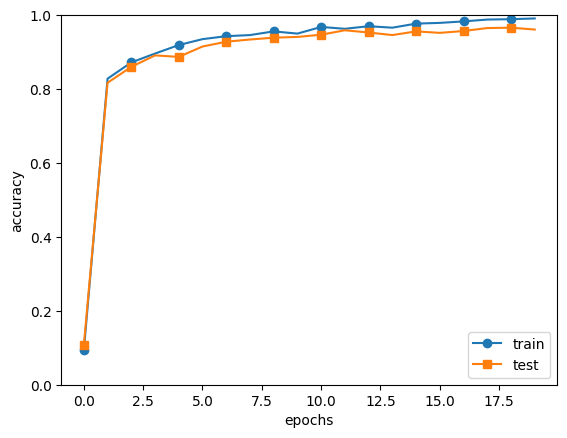

In [ ]:
import sys, os
sys.path.append(os.pardir)  # 为了导入父目录的文件而进行的设定
import numpy as np
import matplotlib.pyplot as plt
from dataset.mnist import load_mnist
from simple_convnet import SimpleConvNet
from common.trainer import Trainer

# 读入数据
(x_train, t_train), (x_test, t_test) = load_mnist(flatten=False) # 读入数据时不展开

# 处理花费时间较长的情况下减少数据 
x_train, t_train = x_train[:5000], t_train[:5000]
x_test, t_test = x_test[:1000], t_test[:1000]

max_epochs = 20

network = SimpleConvNet(input_dim=(1,28,28), 
                        conv_param = {'filter_num': 30, 'filter_size': 5, 'pad': 0, 'stride': 1},
                        hidden_size=100, output_size=10, weight_init_std=0.01)
                        
trainer = Trainer(network, x_train, t_train, x_test, t_test,
                  epochs=max_epochs, mini_batch_size=100,
                  optimizer='Adam', optimizer_param={'lr': 0.001},
                  evaluate_sample_num_per_epoch=1000)
trainer.train()

# 保存参数
network.save_params("params.pkl")
print("Saved Network Parameters!")

# 绘制图形
markers = {'train': 'o', 'test': 's'}
x = np.arange(max_epochs)
plt.plot(x, trainer.train_acc_list, marker='o', label='train', markevery=2)
plt.plot(x, trainer.test_acc_list, marker='s', label='test', markevery=2)
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.ylim(0, 1.0)
plt.legend(loc='lower right')
plt.show()


## CNN的可视化 
### 第1层权重的可视化
刚才我们对MNIST数据集进行了简单的CNN学习。当时，第1层的卷积层的权重的形状是$(30, 1, 5, 5)$，即30个大小为$5×5$、通道为1的滤波器。滤波器大小是$5×5$、通道数是1，意味着滤波器可以可视化为1通道的灰度图像。现在，我们将卷积层（第1层）的滤波器显示为图像。这里，我们来比较一下学习前和学习后的权重，结果如图所示。

图中，学习前的滤波器是随机进行初始化的，所以在黑白的浓淡上没有规律可循，但学习后的滤波器变成了有规律的图像。我们发现，通过学习，滤波器被更新成了有规律的滤波器，比如从白到黑渐变的滤波器、含有块状区域（称为blob）的滤波器等。

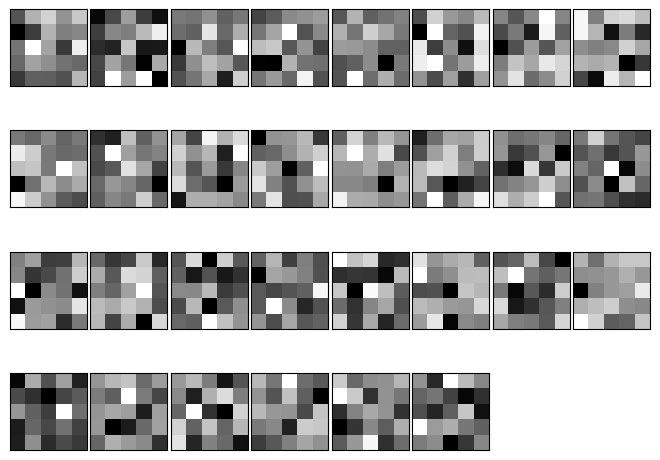

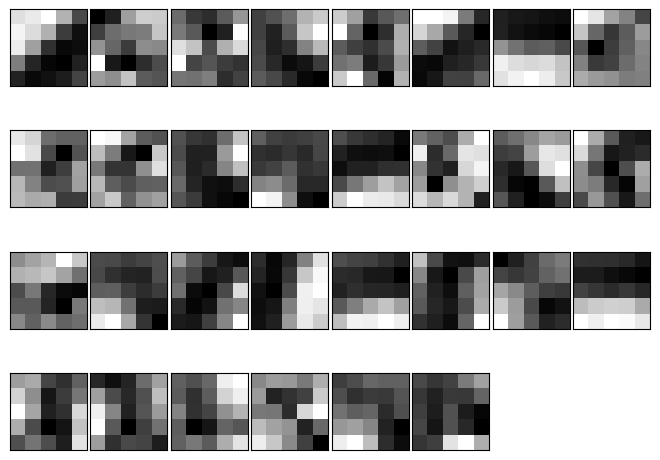

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from simple_convnet import SimpleConvNet

def filter_show(filters, nx=8, margin=3, scale=10):
    FN, C, FH, FW = filters.shape
    ny = int(np.ceil(FN / nx))

    fig = plt.figure()
    fig.subplots_adjust(left=0, right=1, bottom=0, top=1, hspace=0.05, wspace=0.05)

    for i in range(FN):
        ax = fig.add_subplot(ny, nx, i+1, xticks=[], yticks=[])
        ax.imshow(filters[i, 0], cmap=plt.cm.gray_r, interpolation='nearest')
    plt.show()


network = SimpleConvNet()
# 随机进行初始化后的权重
filter_show(network.params['W1'])

# 学习后的权重
network.load_params("params.pkl")
filter_show(network.params['W1'])

如果要问图中右边的有规律的滤波器在“观察”什么，答案就是它在观察边缘（颜色变化的分界线）和斑块（局部的块状区域）等。比如，左半部分为白色、右半部分为黑色的滤波器的情况下，如下图所示，会对垂直方向上的边缘有响应。

<img src="./fig/CNN_edge.png" alt="CNN_edge" style="display: block; margin: 0 auto;">

图中显示了选择两个学习完的滤波器对输入图像进行卷积处理时的结果。我们发现“滤波器1”对垂直方向上的边缘有响应，“滤波器2”对水平方向上的边缘有响应。

由此可知，卷积层的滤波器会提取边缘或斑块等原始信息。而刚才实现的CNN会将这些原始信息传递给后面的层。

### 基于分层结构的信息提取
上面的结果是针对第1层的卷积层得出的。第1层的卷积层中提取了边缘或斑块等“低级”信息，那么在堆叠了多层的CNN中，各层中又会提取什么样的信息呢？根据深度学习的可视化相关的研究，随着层次加深，提取的信息（正确地讲，是反映强烈的神经元）也越来越抽象。

图中展示了进行一般物体识别（车或狗等）的8层CNN。这个网络结构的名称是下一节要介绍的AlexNet。AlexNet网络结构堆叠了多层卷积层和池化层，最后经过全连接层输出结果。图的方块表示的是中间数据，对于这些中间数据，会连续应用卷积运算。

<img src="./fig/CNN_message.png" alt="CNN_message" style="display: block; margin: 0 auto;">

如图所示，如果堆叠了多层卷积层，则随着层次加深，提取的信息也愈加复杂、抽象，这是深度学习中很有意思的一个地方。最开始的层对简单的边缘有响应，接下来的层对纹理有响应，再后面的层对更加复杂的物体部件有响应。也就是说，随着层次加深，神经元从简单的形状向“高级”信息变化。换句话说，就像我们理解东西的“含义”一样，响应的对象在逐渐变化。

## 具有代表性的 CNN 
### LeNet
LeNet在1998年被提出，是进行手写数字识别的网络。如图所示，它有连续的卷积层和池化层（正确地讲，是只“抽选元素”的子采样层），最后经全连接层输出结果。

<img src="./fig/LeNet.png" alt="LeNet" style="display: block; margin: 0 auto;">

和“现在的CNN”相比，LeNet有几个不同点。第一个不同点在于激活函数。LeNet中使用sigmoid函数，而现在的CNN中主要使用ReLU函数。此外，原始的LeNet中使用子采样（subsampling）缩小中间数据的大小，而现在的CNN中Max池化是主流。

综上，LeNet与现在的CNN虽然有些许不同，但差别并不是那么大。想到LeNet是20多年前提出的最早的CNN，还是很令人称奇的。

### AlexNet
在LeNet问世20多年后，AlexNet被发布出来。AlexNet是引发深度学习热潮的导火线，不过它的网络结构和LeNet基本上没有什么不同，如图所示。

<img src="./fig/AlexNet.png" alt="AlexNet" style="display: block; margin: 0 auto;">

AlexNet叠有多个卷积层和池化层，最后经由全连接层输出结果。虽然结构上AlexNet和LeNet没有大的不同，但有以下几点差异。

- 激活函数使用ReLU。
- 使用进行局部正规化的LRN（Local Response Normalization）层。
- 使用Dropout。

如上所述，关于网络结构，LeNet和AlexNet没有太大的不同。但是，围绕它们的环境和计算机技术有了很大的进步。具体地说，现在任何人都可以获得大量的数据。而且，擅长大规模并行计算的GPU得到普及，高速进行大量的运算已经成为可能。大数据和GPU已成为深度学习发展的巨大的原动力。

大多数情况下，深度学习（加深了层次的网络）存在大量的参数。因此，学习需要大量的计算，并且需要使那些参数“满意”的大量数据。可以说是GPU和大数据给这些课题带来了希望。

## 小结
- CNN在此前的全连接层的网络中新增了卷积层和池化层。
- 使用im2col函数可以简单、高效地实现卷积层和池化层。
- 通过CNN的可视化，可知随着层次变深，提取的信息愈加高级。
- LeNet和AlexNet是CNN的代表性网络。
- 在深度学习的发展中，大数据和GPU做出了很大的贡献。